In [1]:
from pprint import pprint
import numpy as np
import pandas as pd
from scipy.stats import norm


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Sources: <br>
* SILVERMAN, Density Estimation for Statistics and Data Analysis <br>
* WAND, Kernel Smoothing <br>
* WASSERMAN, All of Nonparametric Statistics

# Studies

In [30]:
import numpy as np

def histogram(
    x: np.ndarray, 
    binwidth: float
) -> list:
    n = len(x)
    # Align the start to the floor of the minimum value
    x_min = np.floor(x.min())
    x_max = np.ceil(x.max())
    
    # Create the edges of the bins
    # We use arange to ensure each step is exactly 'binwidth'
    grid = np.arange(x_min, x_max + binwidth, binwidth)
    
    hist_values = []
    
    # Iterate through the grid to create adjacent bins
    for i in range(len(grid) - 1):
        bin_start = grid[i]
        bin_end = grid[i+1]
        
        # Count points in the current bin [start, end)
        count = np.sum((x >= bin_start) & (x < bin_end))
        
        # Calculate density: f_hat = count / (n * h)
        f_hat = count / (n * binwidth)
        
        # Store as (bin_range_tuple, density)
        hist_values.append(f_hat)

    return grid, hist_values

In [3]:
grid, hist = histogram(
    x = np.array([1.5, 1.7, 1.8, 1.9, 3, 4.9, 5.1]),
    binwidth = 0.5
    )

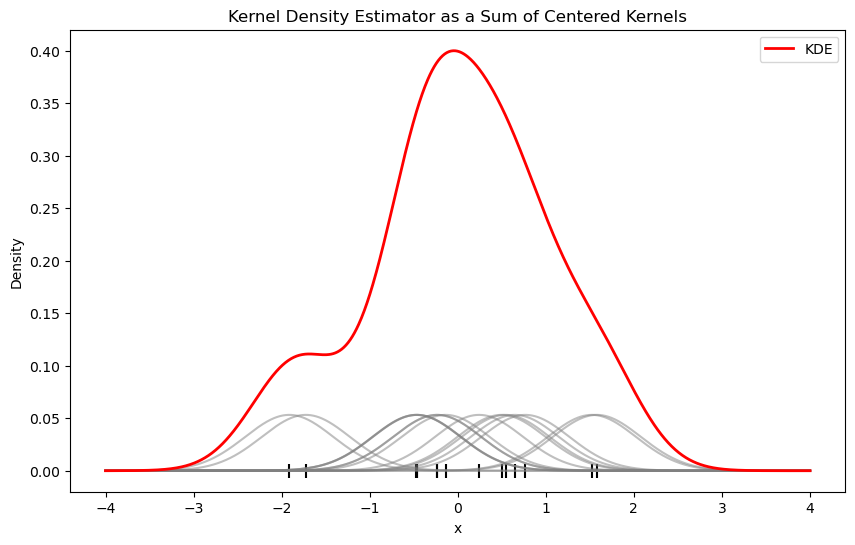

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Sample data
# ---------------------------
np.random.seed(42)
X = np.random.normal(loc=0, scale=1, size=15)
n = len(X)

# ---------------------------
# Parameters
# ---------------------------
h = 0.5  # bandwidth
x_grid = np.linspace(-4, 4, 1000)

# ---------------------------
# Gaussian kernel function
# ---------------------------
def gaussian_kernel(u):
    return norm.pdf(u)  # standard normal kernel

# ---------------------------
# Compute individual kernels
# ---------------------------
kernels = []

for xi in X:
    k = (1 / h) * gaussian_kernel((x_grid - xi) / h)
    kernels.append(k)

kernels = np.array(kernels)

# ---------------------------
# Compute KDE as average
# ---------------------------
kde = (1 / n) * np.sum(kernels, axis=0)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Plot individual centered kernels
for i in range(n):
    plt.plot(x_grid, kernels[i] / n, color='gray', alpha=0.5)

# Plot final KDE
plt.plot(x_grid, kde, color='red', linewidth=2, label='KDE')

# Rug plot
plt.scatter(X, np.zeros_like(X), marker='|', color='black', s=100)

plt.title("Kernel Density Estimator as a Sum of Centered Kernels")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

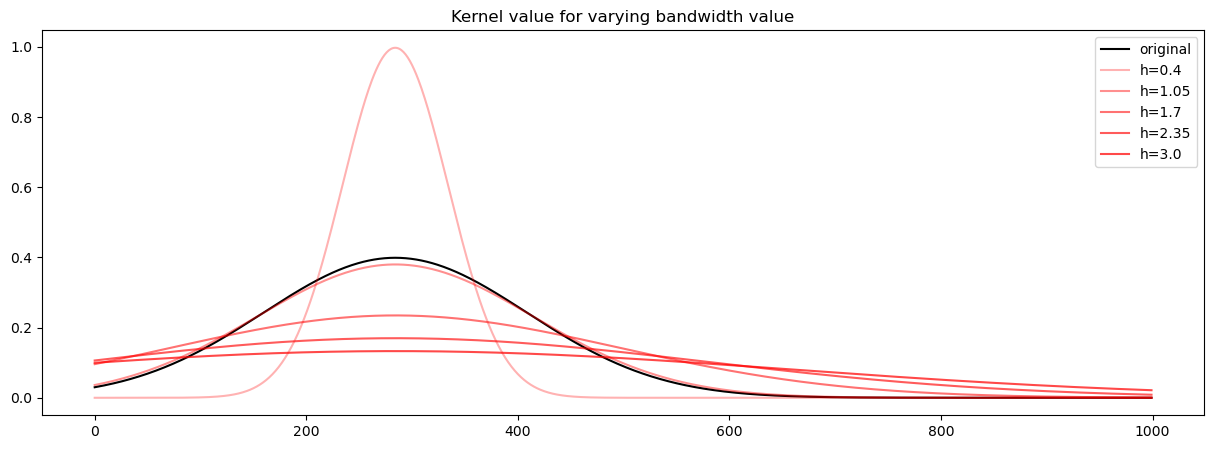

In [5]:
plt.figure(figsize=(15,5))

plt.plot(
    norm.pdf(
        (x_grid - xi)
        )
    , label="original"
    , c="black"
    )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )
#     , label="weighed"
#     )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )/h
#     , label="weighed_2"
#     )

alpha0 = 0.3
steps = 5
for h in np.linspace(0.4, 3, steps):
    plt.plot(
        norm.pdf(
            (x_grid - xi)/h
            )/h
        , label=f"h={h:.3}"
        , color="red"
        , alpha=alpha0
        )
    
    alpha0 += (1-alpha0)/steps

plt.title("Kernel value for varying bandwidth value")
plt.legend()
plt.show()

# Development

In [ ]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut, KFold
from sklearn.neighbors import KernelDensity
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from typing import Union, Optional, Iterable, Any, List
from scipy import stats
import warnings
from scipy.stats import norm, t

## Single observation

In [3]:
AVAILABLE_KERNELS = ["gaussian", "epanechnikov", "t-student"]

In [4]:
def get_rot_bandwidth_ck():
    # Kernel-dependent constants for bandwidth selection
    CK_GAUSSIAN_SILVERMAN = 1.06
    CK_GAUSSIAN_SILVERMAN_ADJUSTED = 0.9
    CK_EPANECHNIKOV_SILVERMAN = 2.34

    ROT_BANDWIDTH_CK = {
        "gaussian": {
            "silverman":          CK_GAUSSIAN_SILVERMAN,
            "silverman_adjusted": CK_GAUSSIAN_SILVERMAN_ADJUSTED,

        },
        "epanechnikov": {
            "silverman":          CK_EPANECHNIKOV_SILVERMAN,
            # "silverman_adjusted": CK_GAUSSIAN_SILVERMAN_ADJUSTED * CK_EPANECHNIKOV_SILVERMAN / CK_GAUSSIAN_SILVERMAN # scaled to preserve Silverman/Gaussian ratio
        },
    }
    return ROT_BANDWIDTH_CK

In [ ]:
def _gaussian_kernel(self, u):
    """
    Gaussian kernel.
    """
    return norm.pdf(u)

def _t_student_kernel(self, u, df):
    """
    Student-t kernel.

    Parameters
    ----------
    df : int
        Degrees of freedom.
    """
    return t.pdf(u, df=df)

def _epanechnikov_kernel(self, u):
    """
    Epanechnikov kernel.
    """
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1)

def _pilot_density(
        X, 
        h,
        kernel: str = "gaussian",
        **kwargs
        ):
    """
    Compute pilot density estimate at sample points.
    """

    # Convert to NumPy array
    X = np.asarray(X, dtype=float)

    # Pairwise standardized distances:
    # u_ij = (X_i - X_j) / h
    u = (X[:, None] - X[None, :]) / h

    # Gaussian kernel evaluation
    if kernel=="t-student":
        pdf = _t_student_kernel(u, **kwargs)
    else:
        pdf = _gaussian_kernel(u)

    # KDE formula evaluated at sample points
    f_pilot = np.mean(pdf / h, axis=1)

    return f_pilot

def _optimize_sklearn(X, bandwidths, cv, kernel):
    """Internal helper for standard Scikit-Learn kernels."""
    grid = GridSearchCV(
        estimator=KernelDensity(kernel=kernel),
        param_grid={"bandwidth": bandwidths},
        cv=cv,
        n_jobs=-1
    )
    grid.fit(X.reshape(-1, 1))
    return grid.best_params_["bandwidth"]

def _optimize_t_student(X, bandwidths, cv, df=3):
    """Internal helper for manual Student-t LCV."""
    max_log_lik = -np.inf
    best_h = bandwidths[0]
    
    # If cv is LeaveOneOut, cv.split(X) works natively. 
    # If int/KFold, it also works.
    for h in bandwidths:
        fold_log_liks = []
        for train_idx, val_idx in cv.split(X):
            train, val = X[train_idx], X[val_idx]
            
            # Distance matrix (n_val, n_train)
            u = (val[:, None] - train[None, :]) / h
            # Student-t Density: f_hat = (1/nh) * sum( K(u) )
            densities = stats.t.pdf(u, df=df) / h
            f_hat = np.mean(densities, axis=1)
            
            # Log-likelihood (with numerical floor)
            fold_log_liks.append(np.sum(np.log(np.maximum(f_hat, 1e-300))))
            
        avg_log_lik = np.mean(fold_log_liks)
        if avg_log_lik > max_log_lik:
            max_log_lik = avg_log_lik
            best_h = h
    return best_h

In [20]:
class BandwidthSelector:
    def __init__(
            self,
            X: pd.Series
        ):
        self.X = X
        self.n = X.shape[0]

    def rot_constants(self) -> List[tuple]:
        rot_elements = get_rot_bandwidth_ck()
        combinations = [
                        (kernel, rule, value) 
                        for kernel, rules in rot_elements.items() 
                        for rule, value in rules.items()
        ]
        
        return combinations

    def rot(
            self,
            kernel:       str = "gaussian", 
            rule:         str = "silverman",
            sigma_robust: bool = False,
            return_list:  bool = True
        ) -> Union[float, np.array]:
        """
            Compute the Rule of Thumb (ROT) bandwidth for Kernel Density Estimation.

            This method provides a closed-form estimate of the optimal bandwidth (h) 
            based on the assumption that the underlying distribution is approximately 
            normal. It is significantly faster than Cross-Validation but may 
            over-smooth multimodal distributions.

            Parameters
            ----------
            kernel_rule : list of str, default=["gaussian", "silverman"]. See get_rot_bandwidth_ck()
            for available constants.
                A pair defining the kernel type and the specific rule:
                - Index 0: Kernel name (e.g., "gaussian", "epanechnikov").
                - Index 1: Rule variant (e.g., "silverman").
            sigma_robust : bool, default=False
                If True, uses a robust estimator of scale: min(std, IQR/1.349).
                This prevents outliers from artificially inflating the bandwidth 
                (over-smoothing).
            return_list : bool, default=True
                - If True, returns a NumPy array of length 'n' where every entry is 
                the calculated bandwidth.
                - If False, returns a single float value for the global bandwidth.

            Returns
            -------
            bandwidth : float or np.ndarray
                The calculated bandwidth(s).

            Notes
            -----
            The bandwidth is calculated using the formula:
                h = C_k * σ * n^(-1/5)
            
            where:
            - C_k is a kernel-specific constant (e.g., 1.06 for Silverman's Gaussian).
            - σ is the standard deviation (or robust alternative).
            - n is the sample size.

            References
            ----------
            Silverman, B. W. (1986). Density Estimation for Statistics and Data Analysis.
            Scott, D. W. (1992). Multivariate Density Estimation.
        """
        c_k = get_rot_bandwidth_ck()[kernel][rule]

        standard_deviation = np.std(self.X, axis=0)
        if sigma_robust:
            iqr_x = np.subtract(*np.percentile(self.X, [75, 25])) / 1.349
            standard_deviation = np.min([standard_deviation, iqr_x]) if iqr_x > 0 else standard_deviation

        bandwidth = c_k * standard_deviation * self.n **(-1/5)

        if return_list:
            bandwidth = np.full(self.n, bandwidth)

        return bandwidth
    
    def adaptive_bandwidth(
            self,
            h: int,
            alpha=0.5
        ) -> np.array:
        """
        Compute adaptive local bandwidths using the Abramson (1982) variable kernel method.

        This function implements the "square-root law" for bandwidth adaptation. It 
        scales the global bandwidth 'h' based on a pilot density estimate, allowing 
        the kernel to expand in sparse regions (tails) and contract in dense regions 
        (peaks).

        Parameters
        ----------
        X : ndarray of shape (n_samples,)
            The data points at which to evaluate the pilot density and compute bandwidths.
        h : float
            The global (initial) bandwidth. Usually determined by a rule of thumb 
            (e.g., Silverman's or Scott's rule).
        alpha : float, default=0.5
            The sensitivity parameter. 
            - alpha = 0.5: Abramson’s optimal value, which reduces the bias of the 
                KDE from O(h²) to O(h⁴).
            - alpha = 0: Results in a fixed bandwidth h.
            - 0 < alpha < 1: Varying degrees of local adaptation.

        Returns
        -------
        bandwidths : ndarray of shape (n_samples,)
            The local bandwidth values λ(X_i) * h for each point in X.

        Notes
        -----
        The adaptive bandwidth is calculated as:
            h_i = h * (f_pilot(X_i) / g)^(-alpha)

        where 'g' is the geometric mean of the pilot density f_pilot(X):
            log(g) = (1/n) * Σ log(f_pilot(X_i))

        This geometric mean normalization ensures that the product of the local 
        bandwidths remains proportional to the global bandwidth h, maintaining 
        the overall smoothing scale.

        References
        ----------
        Abramson, I. S. (1982). On bandwidth variation in kernel estimates-a 
        square root law. Annals of Statistics, 10(4), 1217-1223.
        """

        f_pilot = _pilot_density(self.X, h)

        # Numerical safety
        eps = np.finfo(float).eps
        f_pilot = np.maximum(f_pilot, eps)

        g = np.exp(np.mean(np.log(f_pilot)))

        bandwidths = h * (f_pilot / g) ** (-alpha)

        return bandwidths
        
    def cross_validate_bandwidth(
            self,
            bandwidths_grid: Optional[Iterable[float]] = None,
            cv: Union[int, str] = 5,
            kernel: str = "gaussian",
            return_list: bool = True,
            **kernel_kwargs: Any
        ) -> Union[float, np.array]:
        """
        Select optimal KDE bandwidth via Likelihood Cross-Validation (LCV).

        Finds the global scaling factor (h) that maximizes the log-likelihood of 
        out-of-sample observations. This data-driven approach automates the 
        bias-variance tradeoff by optimizing the model's predictive density.

        Parameters
        ----------
        bandwidths_grid : array-like, optional
            Candidate bandwidth values to evaluate. If None, a logarithmic grid 
            is automatically constructed, centered around Silverman's Rule of 
            Thumb (ROT) and scaled by the data's robust volatility.
        cv : int or "LOO", default=5
            The cross-validation strategy:
            - int: Number of folds for K-Fold CV (Recommended for large n).
            - "LOO": Leave-One-Out CV (Classic approach, high computational cost).
        kernel : str, default="gaussian"
            Kernel function for density estimation. Supports Scikit-Learn kernels 
            (gaussian, epanechnikov, etc.) and custom "t-student" implementation.
        return_list : bool, default=True
            - If True: Returns an ndarray of length self.n filled with h_opt.
            - If False: Returns h_opt as a single float.
        **kernel_kwargs : Any
            Additional parameters passed to custom kernels. 
            Example: df=3 for 't-student'.

        Returns
        -------
        bandwidth : float or np.ndarray
            The optimal bandwidth(s) that maximize the cross-validated 
            log-likelihood.

        Notes
        -----
        Likelihood CV is asymptotically equivalent to minimizing the 
        Kullback-Leibler divergence between the estimated and true densities. 
        Unlike Least-Squares CV, LCV is particularly effective for heavy-tailed 
        distributions, though it can be sensitive to extreme outliers.

        Warnings
        --------
        Issues a UserWarning if the selected bandwidth lies on the boundary of 
        the provided or generated grid, suggesting the search space is insufficient.
        """
        # 1. Input Validation and Preparation
        X = np.asarray(self.X, dtype=float).flatten()
        if X.size < 2:
            raise ValueError("Bandwidth estimation requires at least two data points.")
        
        # 2. Automated Grid Generation (Data-Dependent)
        if bandwidths_grid is None:
            std_x = np.std(X, ddof=1)
            iqr_x = np.subtract(*np.percentile(X, [75, 25])) / 1.349
            sigma_robust = np.min([std_x, iqr_x]) if iqr_x > 0 else std_x
            h_rot = 0.9 * sigma_robust * (X.size ** -0.2)
            bandwidths_grid = np.logspace(np.log10(h_rot/10), np.log10(h_rot*10), 50)

        # 3. CV Strategy Dispatch
        cv_strategy = LeaveOneOut() if cv == "LOO" else KFold(n_splits=cv, shuffle=True)

        # 4. Optimization Path Dispatch
        if kernel == "t-student":
            bandwidth = _optimize_t_student(X, bandwidths_grid, cv_strategy, **kernel_kwargs)
        else:
            bandwidth = _optimize_sklearn(X, bandwidths_grid, cv_strategy, kernel)

        # 5. Boundary Warning
        if np.isclose(bandwidth, np.min(bandwidths_grid)) or np.isclose(bandwidth, np.max(bandwidths_grid)):
            
            warnings.warn(
                f"Optimal bandwidth ({bandwidth:.4f}) is at the boundary of the grid for kernel '{kernel}'.", 
                UserWarning
            )

        if return_list:
            bandwidth = np.full(self.n, bandwidth)
        return bandwidth

### Test

In [49]:
X_single = pd.Series(np.random.standard_t(size=5001, df=2), name="date_t")

bw_single = BandwidthSelector(X_single)

In [38]:
bw_single.rot()

array([0.66009211, 0.66009211, 0.66009211, ..., 0.66009211, 0.66009211,
       0.66009211], shape=(5001,))

In [39]:
bw_single.rot(kernel="gaussian", rule="silverman_adjusted", sigma_robust=True)

array([0.19722864, 0.19722864, 0.19722864, ..., 0.19722864, 0.19722864,
       0.19722864], shape=(5001,))

In [40]:
bw_single.adaptive_bandwidth(
                    h = bw_single.rot(kernel="gaussian", rule="silverman_adjusted", sigma_robust=True, return_list=False)
)

array([0.40897251, 0.128376  , 0.12812271, ..., 0.13362452, 0.32862217,
       0.23254489], shape=(5001,))

In [ ]:
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv=10
)

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_3595/554080958.py:224: UserWarning: Optimal bandwidth (2.0875) is at the boundary of the grid for kernel 'gaussian'.
  warnings.warn(


array([2.08748805, 2.08748805, 2.08748805, ..., 2.08748805, 2.08748805,
       2.08748805], shape=(5001,))

In [ ]:
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv="LOO"
)

array([1.90285276, 1.90285276, 1.90285276, ..., 1.90285276, 1.90285276,
       1.90285276], shape=(5001,))

In [ ]:
bw_single.cross_validate_bandwidth(
    kernel="t-student",
    df=3,
    cv=5
)

array([0.4230035, 0.4230035, 0.4230035, ..., 0.4230035, 0.4230035,
       0.4230035], shape=(5001,))

### Execution time for LOO vs Kfold

In [ ]:
%%timeit
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv="LOO"
)

35.7 s ± 5.81 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv=5
)

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_3595/554080958.py:224: UserWarning: Optimal bandwidth (2.0904) is at the boundary of the grid for kernel 'gaussian'.
  warnings.warn(


2.49 s ± 13.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## For dataframe

In [28]:
def df_bandwidth_selector(
        df: pd.DataFrame,
        method: str = "rot",
        # return_list: bool = True,
        **kwargs
    ) -> pd.DataFrame:
    """
    Apply a bandwidth selection method column-wise to a DataFrame.

    This function treats each column of `df` as an independent univariate 
    sample and applies a selected method from the `BandwidthSelector` class.
    The selected method is evaluated separately for each column, and the 
    results are stacked into a DataFrame.

    By default, most bandwidth methods in `BandwidthSelector` return a 
    length-n vector (where n is the number of observations in that column).
    Using `result_type="expand"` ensures that these vectors are expanded 
    into a DataFrame with the same row dimension as the input.

    Parameters
    ----------
    df : pd.DataFrame
        Input data where:
        - Each column represents an independent sample (e.g., one density).
        - Each row represents an observation.
        Missing values are automatically removed column-wise before 
        bandwidth computation.

    method : str, default="rot"
        Name of the method from the `BandwidthSelector` class to apply.
        Examples include:
        - "rot"
        - "cross_validate_bandwidth"
        - "adaptive_bandwidth"

    **kwargs : dict
        Additional keyword arguments passed directly to the selected 
        bandwidth method.

        Examples:
        - kernel="gaussian"
        - cv=5
        - df=3   (for t-student kernel)
        - alpha=0.5

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the bandwidth outputs for each column:

        - If the selected method returns a scalar (e.g., return_list=False),
          the output will be a single-row DataFrame.
        - If the selected method returns a length-n array (default behavior),
          the output will have the same number of rows as the input DataFrame.

        Columns correspond to the original column names of `df`.

    Notes
    -----
    1. Each column is processed independently.
    2. No interaction between columns is assumed.
    3. Missing values are dropped before bandwidth estimation.
    4. This function does not perform density estimation — it only computes
       bandwidths.

    Examples
    --------
    >>> import numpy as np
    >>> import pandas as pd
    >>> np.random.seed(123)

    Create synthetic data (100 columns, heavy-tailed samples):

    >>> n_cols = 3
    >>> X = pd.DataFrame(
    ...     np.random.standard_t(df=2, size=(500, n_cols)),
    ...     columns=[f"series_{i}" for i in range(n_cols)]
    ... )

    Example 1 — Rule of Thumb (Gaussian kernel):

    >>> h_rot = df_bandwidth_selector(X, method="rot", kernel="gaussian")
    >>> h_rot.head()

    Example 2 — Likelihood Cross-Validation:

    >>> h_lcv = df_bandwidth_selector(
    ...     X,
    ...     method="cross_validate_bandwidth",
    ...     kernel="gaussian",
    ...     cv=5
    ... )

    Example 3 — Student-t kernel with 3 degrees of freedom:

    >>> h_t = df_bandwidth_selector(
    ...     X,
    ...     method="cross_validate_bandwidth",
    ...     kernel="t-student",
    ...     df=3
    ... )

    Example 4 — Adaptive bandwidth (Abramson method):

    >>> h_adaptive = df_bandwidth_selector(
    ...     X,
    ...     method="adaptive_bandwidth",
    ...     h=0.2,
    ...     alpha=0.5
    ... )

    In this case, the output contains local bandwidths for each observation
    in each column.

    See Also
    --------
    BandwidthSelector : Class implementing individual bandwidth methods.
    """
    
    results = {}
    for col_name in df.columns:
        clean_col = df[col_name].dropna()
        # print(clean_col)
        res = getattr(BandwidthSelector(clean_col), method)(**kwargs)
        # print(res)
        
        # Ensure we return a full-length array even if we dropped NaNs
        if np.isscalar(res):
            results[col_name] = np.full(len(df), res)
        else:
            results[col_name] = res
                
    return pd.DataFrame(results, index=df.index)

In [32]:
n_cols = 100
X = pd.DataFrame(np.random.standard_t(size=[5001, n_cols], df=2), columns=[f"date_{t}" for t in range(n_cols)])
bw_from_df = BandwidthSelector(X.iloc[:,0])

df_bandwidth_selector(X, method="rot", kernel="epanechnikov", rule="silverman")

,date_0,date_1,date_2,date_3,date_4,date_5,date_6,date_7,date_8,date_9,...,date_90,date_91,date_92,date_93,date_94,date_95,date_96,date_97,date_98,date_99
0,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
1,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
2,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
3,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
4,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
4997,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
4998,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852
4999,1.116498,1.207551,1.109354,1.547329,1.151478,1.416169,1.558738,5.185194,1.165304,1.263794,...,1.065466,1.39194,1.599637,1.187866,1.180907,1.488493,1.488079,1.127053,1.321868,1.453852


In [34]:
df_bandwidth_selector(X, method="adaptive_bandwidth", h = bw_from_df.rot(kernel="gaussian", rule="silverman_adjusted", sigma_robust=True))

,date_0,date_1,date_2,date_3,date_4,date_5,date_6,date_7,date_8,date_9,...,date_90,date_91,date_92,date_93,date_94,date_95,date_96,date_97,date_98,date_99
0,0.150537,0.133191,0.142502,0.138085,0.134469,0.132735,0.132021,0.128308,0.136605,0.330459,...,0.233975,0.313249,0.150690,0.136332,0.125522,0.129759,0.225085,0.434551,0.138739,0.162367
1,0.241343,0.129172,0.131068,0.139805,0.129647,0.358532,0.129825,0.139075,0.323338,0.560702,...,0.129037,0.452775,0.129891,0.323485,0.278351,0.146381,0.138315,0.185647,0.128502,0.703664
2,0.150165,0.605773,0.144682,0.133601,0.148461,0.146285,0.143955,1.445158,0.135470,0.128690,...,0.137572,0.148104,0.164402,0.132909,0.683522,0.373582,0.178451,0.144842,0.127480,0.132036
3,0.498421,0.164821,0.148910,0.137945,0.152875,0.135590,0.129851,0.265088,0.134877,0.217001,...,0.265265,0.139707,0.140922,0.185044,0.301953,0.148748,0.141618,0.639728,0.217062,0.478223
4,0.146765,0.190261,0.129781,0.153967,0.191295,0.138327,0.152654,0.155741,0.131730,0.178798,...,0.134699,1.091328,0.130026,0.128297,0.136250,0.144177,0.131835,0.159747,0.127385,0.145463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0.570581,0.130494,0.187744,0.164715,0.167795,0.272575,0.168533,0.146020,0.167915,0.142614,...,0.139194,0.127020,0.267464,2.207814,0.381947,0.139391,0.131025,0.127793,0.128803,0.147665
4997,0.259974,0.129722,0.130786,0.130489,0.495340,0.209489,0.134169,0.288672,0.136772,0.174608,...,0.190110,0.133534,0.168752,0.128712,0.244944,0.133330,0.322207,0.133860,0.427236,0.168931
4998,0.148441,0.245121,1.371570,0.140327,0.218891,0.834656,0.129263,0.130909,0.319555,0.186586,...,0.132925,0.236167,0.179549,0.129652,0.155635,0.220125,0.324796,0.330536,0.144545,3.159679
4999,0.175539,0.129171,0.219715,0.156369,0.254003,0.265517,0.135302,0.139372,0.131767,0.224528,...,0.133591,0.126709,0.284362,0.138268,0.195609,0.182466,0.136890,0.128627,0.130037,0.131336


In [ ]:
df_bandwidth_selector(X, kernel="t-student", method="cross_validate_bandwidth", cv=5)

# Cleaned KDE class

In [ ]:
class KernelDensityEstimation:
    """
    Description
    ---------
    Kernel Density Estimation for (functional) data.

    Supports multiple kernels and observation-specific bandwidths.

    Example
    ---------
    >>>x1 = np.random.randn(200)
    >>>x2 = np.random.standard_t(df=3, size=200)
    >>>grid = np.linspace(-4, 4, 400)

    >>>kde = FDA_KDE(kernel="gaussian", bandwidth=0.3)
    >>>density = kde.fit_transform(x1, grid)
    >>>density_grid = kde.grid

    >>>params = {"kernel": "t_student", "bandwidth": "scorr", "df": 3, "adaptive": True}
    >>>t_kde = FDA_KDE(**params)
    >>>t_density = t_kde.fit_transform(x2)
    """

    def __init__(
            self, 
            kernel="gaussian", 
            **kernel_params
            ):
        """
        Parameters
        ----------
        kernel : str
            Kernel name. Available: 'gaussian', 't_student', 'epanechnikov'.
        bandwidth : float or array-like
            Scalar or observation-specific bandwidth(s).
        **kernel_params :
            Additional parameters passed to the kernel
            (e.g., df for Student-t kernel).
        """
        self.kernel = kernel
        self.kernel_params = kernel_params
        self.model_name = f"kernel: {self.kernel}"
        # self.df = df

        # Kernel registry (instance-level, extensible)
        self._kernel_map = {
            "gaussian": self._gaussian_kernel,
            "t_student": self._t_student_kernel,
            "epanechnikov": self._epanechnikov_kernel,
        }

        # Attributes set after fitting
        self.X_   = None
        self.h_   = None
        self.grid = None

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def transform(
            self, 
            grid
        ):
        """
        Evaluate the KDE on a given grid.

        Parameters
        ----------
        grid : array-like, shape (n_grid,)
            Evaluation points.

        Returns
        -------
        density : ndarray, shape (n_grid,)
            Estimated density values.
        """
        self._check_is_fitted()

        grid = np.asarray(grid, dtype=float)

        # Standardized distances: u_ij = (grid_i - X_j) / h_j
        u = (grid[:, None] - self.X_[None, :]) / self.h_[None, :]

        pdf = self._evaluate_kernel(u)

        # KDE: mean_j K(u_ij) / h_j
        density = np.mean(pdf / self.h_[None, :], axis=1).astype(float)

        return density

    def fit_transform(
            self, 
            X : np.array, 
            m : int = 5001,
            grid=None
        ):
        """
        Fit the model and evaluate the KDE on a grid.
        """
        if grid is None:
            grid = np.linspace(X.min(), X.max(), m)

        self.grid = grid
        return self.fit(X, adaptive=self.adaptive).transform(grid)

    # ------------------------------------------------------------------
    # Kernel evaluation
    # ------------------------------------------------------------------


    def _gaussian_kernel(self, u):
        """
        Gaussian kernel.
        """
        return norm.pdf(u)

    def _t_student_kernel(self, u, df=5):
        """
        Student-t kernel.

        Parameters
        ----------
        df : int
            Degrees of freedom.
        """
        return t.pdf(u, df=df)
    
    def _epanechnikov_kernel(self, u):
        """
        Epanechnikov kernel.
        """
        return 0.75 * (1 - u**2) * (np.abs(u) <= 1)
 
    def _evaluate_kernel(
            self, 
            u : np.array
        ) -> np.array:
        """
        Evaluate the selected kernel on standardized distances.

        This method dispatches the evaluation of the kernel function
        specified by ``self.kernel`` using the internal kernel registry.
        The kernel is evaluated pointwise on the standardized distances

            u_ij = (x_i - X_j) / h_j,

        where ``x_i`` are evaluation points, ``X_j`` are training
        observations, and ``h_j`` are observation-specific bandwidths.

        Parameters
        ----------
        u : ndarray, shape (n_grid, n_samples)
            Matrix of standardized distances between evaluation points
            and training observations.

        Returns
        -------
        pdf : ndarray, shape (n_grid, n_samples)
            Kernel values evaluated at ``u``.

        Raises
        ------
        ValueError
            If ``self.kernel`` is not a recognized kernel name.

        Notes
        -----
        This method assumes that the selected kernel integrates to one.
        Bandwidth scaling is applied outside this function when computing
        the KDE estimator.
        """
        try:
            kernel_fn = self._kernel_map[self.kernel]
        except KeyError:
            raise ValueError(
                f"Unknown kernel '{self.kernel}'. "
                f"Available kernels: {list(self._kernel_map)}"
            )

        kde = kernel_fn(u, **self.kernel_params)
        
        return kde

    # ------------------------------------------------------------------
    # Utilities
    # ------------------------------------------------------------------

    def _check_is_fitted(self):
        if self.X_ is None or self.h_ is None:
            raise RuntimeError("The estimator is not fitted yet.")

# $h_t$ as input for KDE

In [ ]:
X.head()

In [ ]:
df_bandwidth_selector(X, method="adaptive_bandwidth", h = bw_from_df.rot(kernel="gaussian", rule="silverman_adjusted", sigma_robust=True))

# Cross-validation

In [78]:
from sklearn.model_selection import ParameterGrid

# 1. Define the parameter universes for each method
rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "cv": [5]
}

lcv_t_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["t-student"],
    "df": [df for df in range(2,6)],
    "cv": [5]#, "LOO"]
}

kernel_rules = np.unique([v for d in get_rot_bandwidth_ck().values() for v in d.keys()])
adaptive_grid = {
    "method": ["adaptive_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"],
    "h": kernel_rules
}

# 2. Combine grids and build the dictionary
BANDWIDTH_CONFIGS = {}

for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid]:
    for params in ParameterGrid(grid):
        # Create a unique key based on the parameters
        # e.g., "rot_gaussian_robust_True" or "lcv_t-student_df_3"
        key_parts = [params["method"]]
        if "kernel" in params: key_parts.append(params["kernel"])
        if "df" in params: key_parts.append(f"df{params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        # ADD THESE TWO LINES:
        if "alpha" in params: key_parts.append(f"a{params['alpha']}")
        if "h" in params: key_parts.append(f"h{params['h']}") # Distinguish different pilot h values
        
        name = "_".join(key_parts).replace("-", "").replace(".", "") # Remove dots for cleaner keys
        BANDWIDTH_CONFIGS[name] = params

# View a few examples:
print(BANDWIDTH_CONFIGS["rot_gaussian_robust"])
# print(BANDWIDTH_CONFIGS["lcv_tstudent_df3_loo"])

{'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': True}


In [ ]:
# Na validação cruzada, passar chaves como argumentos das funções
BANDWIDTH_CONFIGS

{'rot_gaussian_robust': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': True},
 'rot_gaussian': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': False},
 'rot_epanechnikov_robust': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': True},
 'rot_epanechnikov': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': False},
 'cross_validate_bandwidth_gaussian': {'cv': 5,
  'kernel': 'gaussian',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_epanechnikov': {'cv': 5,
  'kernel': 'epanechnikov',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df2': {'cv': 5,
  'df': 2,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df3': {'cv': 5,
  'df': 3,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df4': {'cv': 5,
  'df': 4,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_val